# Timepix 探测器数据：可扩展筛选与导出

本笔记本用于从“每个角度一个特征 CSV（features_*.csv） + 每个角度一个原始 txt 文件夹”的数据结构中，按可配置的筛选条件选出指定事件，并将对应 `.txt` 导出到新的数据集目录中，同时保留“总目录/角度子目录”的结构。

## 需要提供/确认
- `RAW_ROOT`：原始 `.txt` 数据集根目录（其下按角度分文件夹，如 `RAW_ROOT/90/*.txt` 或 `RAW_ROOT/angle=90/*.txt`）
- `FEATURE_ROOT`：特征 CSV 根目录（其下按角度分文件夹，如 `FEATURE_ROOT/angle=90/features_90.csv`）
- `OUT_ROOT`：输出根目录（会在其中创建按角度划分的子目录）

## 关键特点
- 筛选条件独立成单元格：以后新增/修改条件只改“筛选条件配置”那一个单元格。
- 角度筛选独立成单元格：支持筛选全部角度或仅指定角度/角度范围。
- 文件名可在不同角度重复：始终按 `angle + file` 定位。


In [114]:
# 1) 导入依赖与全局常量
from __future__ import annotations

from datetime import datetime
import json
import re
from pathlib import Path
from typing import Any, Dict, List, Literal, Optional, Tuple

import numpy as np
import pandas as pd

try:
    from tqdm import tqdm
except Exception:
    tqdm = None

import shutil

# 显示设置
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# 全局常量
DEFAULT_EVENT_SUFFIX = ".txt"
DEFAULT_CSV_ENCODING = "utf-8"
MISSING_VALUE_POLICY: Literal["keep", "drop", "raise"] = "keep"

# 为避免不同平台换行/编码问题，统一用 Path


In [115]:
# 2) 参数与路径配置（CSV 与数据集根目录、输出目录）

# ==== 必改：三大路径 ====
RAW_ROOT = Path(r"E:\C1Analysis\C_Original_Filtered_Cropped")
FEATURE_ROOT = Path(r"E:\C1Analysis\Analysis_C_Original_Filtered_Cropped")
OUT_ROOT = Path(r"E:\C1Analysis\C_Processed_1")

# ==== CSV 列名（如你的 features_90.csv：active_count, active_sum, file）====
FILENAME_COL = "file"
ACTIVE_COUNT_COL = "active_count"
ACTIVE_SUM_COL = "active_sum"

# ==== CSV 读取策略（解决偶发坏行/列数不齐）====
# - 推荐：先用默认 C 引擎，若 ParserError 再降级到 python 引擎
# - CSV_ON_BAD_LINES='warn'：会跳过坏行并给出警告（建议先用 warn）
CSV_ENCODING = DEFAULT_CSV_ENCODING
CSV_ON_BAD_LINES: Literal["error", "warn", "skip"] = "warn"

# ==== 导出行为 ====
DRY_RUN = False          # True: 只生成清单/统计，不复制文件
OVERWRITE = False       # False: 若目标文件存在则跳过
COPY_MODE: Literal["copy2", "copy"] = "copy2"  # copy2 保留时间戳等元信息

# ==== 选择角度：None 表示全部；也可以只筛选指定角度 ====
# 例：ANGLES = ["90", "85"]  或  ANGLES = "90"  或  ANGLES = None
ANGLES: Optional[object] = None

# ==== 阈值 ====
MIN_ACTIVE_COUNT = 5
MIN_ACTIVE_SUM_LB = 4000
MIN_ACTIVE_SUM_UB = 10000

# ==== 可选：抽样自检 ====
SANITY_CHECK_N = 5
RANDOM_SEED = 20260205

OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("RAW_ROOT =", RAW_ROOT)
print("FEATURE_ROOT =", FEATURE_ROOT)
print("OUT_ROOT =", OUT_ROOT)


RAW_ROOT = E:\C1Analysis\C_Original_Filtered_Cropped
FEATURE_ROOT = E:\C1Analysis\Analysis_C_Original_Filtered_Cropped
OUT_ROOT = E:\C1Analysis\C_Processed_1


In [116]:
# 3) 筛选条件配置单元格（独立、可扩展）
# 说明：只在这里“声明条件”，不要把业务流程写死在这里。
# 新增条件：往 CONDITIONS 里追加一个 dict，或新增一个 callable 条件。

ConditionType = Literal["range", "equals", "in", "notin", "regex", "custom"]

# 每条条件结构示例：
# {
#   'name': 'active_count_gt_5',
#   'enabled': True,
#   'type': 'range',
#   'field': 'active_count',
#   'params': {'min': 5, 'min_inclusive': False},
#   'description': '激活像素数 > 5'
# }

CONDITIONS: List[Dict[str, Any]] = [
    {
        "name": "active_count_gt",
        "enabled": True,
        "type": "range",
        "field": ACTIVE_COUNT_COL,
        "params": {"min": MIN_ACTIVE_COUNT, "min_inclusive": False},
        "description": "单个事件激活像素数 > MIN_ACTIVE_COUNT",
        "priority": 10,
    },
    {
        "name": "active_sum",
        "enabled": True,
        "type": "range",
        "field": ACTIVE_SUM_COL,
        #"params": {"min": MIN_ACTIVE_SUM_LB, "max": MIN_ACTIVE_SUM_UB, "min_inclusive": False, "max_inclusive": False},
        "params": {"max": MIN_ACTIVE_SUM_UB, "max_inclusive": False},
        "description": "单个事件激活像素值总和在 MIN_ACTIVE_SUM_LB 和 MIN_ACTIVE_SUM_UB 之间",
        "priority": 20,
    },
]
    
# 复杂条件（例如依赖多列、或需要自定义逻辑）可以用 custom：
# 注意：callable 接收 df，返回与 df 等长的 bool mask。
# CUSTOM_CONDITION_EXAMPLE = {
#     "name": "my_custom",
#     "enabled": False,
#     "type": "custom",
#     "callable": lambda df: (df["active_max"] > 1000) & (df["bbox_aspect_ratio"] < 2.0),
#     "description": "示例：active_max 很大且长宽比小",
# }
# CONDITIONS.append(CUSTOM_CONDITION_EXAMPLE)

# 组合方式：默认 AND（所有启用条件都满足才通过）
CONDITION_COMBINE: Literal["and", "or"] = "and"


In [117]:
# 4) 角度筛选配置单元格（全部/指定角度）
# 说明：角度筛选与其他筛选条件分离，便于你只改这里来选角度。

AngleMode = Literal["all", "select"]

ANGLE_CFG: Dict[str, Any] = {
    # mode='all'：处理 FEATURE_ROOT 下检测到的全部角度（或 RAW_ROOT 下全部角度）
    # mode='select'：只处理指定 angles 或范围
    "mode": "select",

    # 离散角度列表：如 ["85", "90"] 或 [85, 90]
    "angles": [],

    # 范围筛选（可选）：例如 80~90
    "angle_min": 70,
    "angle_max": None,

    # 单位说明（仅用于展示）
    "unit": "deg",
}

# 如果你想只筛选某一个角度：
# ANGLE_CFG["mode"] = "select"
# ANGLE_CFG["angles"] = ["90"]

# 如果你想筛选范围：
# ANGLE_CFG["mode"] = "select"
# ANGLE_CFG["angle_min"] = 80
# ANGLE_CFG["angle_max"] = 90


In [118]:
# 5) 读取 CSV 索引并校验与数据集文件一一对应

def _coerce_angle(x: Any) -> str:
    # 统一把角度作为字符串目录名使用（例如 '90'）
    if x is None:
        return ""
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)):
        if float(x).is_integer():
            return str(int(x))
        return str(x)
    return str(x).strip()


def normalize_angles_param(angles: Optional[object]) -> Optional[List[str]]:
    if angles is None:
        return None
    if isinstance(angles, str):
        return [_coerce_angle(angles)]
    if isinstance(angles, (list, tuple, set)):
        return [_coerce_angle(a) for a in angles]
    return [_coerce_angle(angles)]


def discover_angles_from_feature_root(feature_root: Path) -> List[str]:
    # 兼容：feature_root/angle=90/features_90.csv
    angles: List[str] = []
    if not feature_root.exists():
        return angles
    for p in feature_root.iterdir():
        if p.is_dir() and p.name.startswith("angle="):
            angles.append(p.name.split("=", 1)[1])
    angles = sorted(set(_coerce_angle(a) for a in angles), key=lambda s: float(s) if re.fullmatch(r"\d+(?:\.\d+)?", s) else s)
    return angles


def find_feature_csv(angle: str) -> Path:
    # 默认结构：FEATURE_ROOT/angle=90/features_90.csv
    return FEATURE_ROOT / f"angle={angle}" / f"features_{angle}.csv"


def find_raw_dir(angle: str) -> Path:
    # 兼容两种结构：RAW_ROOT/90 或 RAW_ROOT/angle=90
    cand1 = RAW_ROOT / str(angle)
    if cand1.exists():
        return cand1
    cand2 = RAW_ROOT / f"angle={angle}"
    return cand2


def resolve_angles_to_process() -> List[str]:
    # 1) 优先使用 ANGLE_CFG
    mode: str = ANGLE_CFG.get("mode", "all")
    if mode not in ("all", "select"):
        raise ValueError(f"ANGLE_CFG['mode'] must be 'all' or 'select', got {mode!r}")

    discovered = discover_angles_from_feature_root(FEATURE_ROOT)

    if mode == "all":
        # 允许用户用 ANGLES 参数再做一次“手动限定”（可选）
        angles_user = normalize_angles_param(ANGLES)
        if angles_user is None:
            return discovered
        return [a for a in discovered if a in set(angles_user)]

    # select 模式
    angles_list = normalize_angles_param(ANGLE_CFG.get("angles"))
    if angles_list:
        return angles_list

    a_min = ANGLE_CFG.get("angle_min")
    a_max = ANGLE_CFG.get("angle_max")
    if a_min is None and a_max is None:
        raise ValueError("ANGLE_CFG mode='select' 时必须提供 angles 或 angle_min/angle_max")

    def _to_float(s: str) -> Optional[float]:
        try:
            return float(s)
        except Exception:
            return None

    picked: List[str] = []
    for a in discovered:
        af = _to_float(a)
        if af is None:
            continue
        if a_min is not None and af < float(a_min):
            continue
        if a_max is not None and af > float(a_max):
            continue
        picked.append(a)
    return picked


def validate_inputs(angles: List[str]) -> pd.DataFrame:
    rows = []
    for a in angles:
        f_csv = find_feature_csv(a)
        raw_dir = find_raw_dir(a)
        rows.append({
            "angle": a,
            "feature_csv": str(f_csv),
            "feature_csv_exists": f_csv.exists(),
            "raw_dir": str(raw_dir),
            "raw_dir_exists": raw_dir.exists(),
        })
    return pd.DataFrame(rows)


angles_to_process = resolve_angles_to_process()
print("angles_to_process:", angles_to_process)

df_inputs = validate_inputs(angles_to_process)
df_inputs

angles_to_process: ['70', '75', '80', '82', '83', '84', '85', '86', '88', '90']


,angle,feature_csv,feature_csv_exists,raw_dir,raw_dir_exists
0,70,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\70,True
1,75,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\75,True
2,80,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\80,True
3,82,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\82,True
4,83,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\83,True
5,84,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\84,True
6,85,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\85,True
7,86,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\86,True
8,88,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\88,True
9,90,E:\C1Analysis\Analysis_C_Original_Filtered_Cro...,True,E:\C1Analysis\C_Original_Filtered_Cropped\90,True


In [119]:
# 6) 实现可扩展的筛选器（条件注册/组合/链式应用）

def apply_condition(df: pd.DataFrame, cond: Dict[str, Any], *, missing_policy: str = MISSING_VALUE_POLICY) -> pd.Series:
    if not cond.get("enabled", True):
        return pd.Series(True, index=df.index)

    ctype: str = cond.get("type")

    if ctype == "custom":
        fn = cond.get("callable")
        if not callable(fn):
            raise ValueError(f"custom condition {cond.get('name')} missing callable")
        mask = fn(df)
        if not isinstance(mask, (pd.Series, np.ndarray, list)):
            raise ValueError("custom callable must return array-like mask")
        return pd.Series(mask, index=df.index).astype(bool)

    field = cond.get("field")
    if field is None:
        raise ValueError(f"condition {cond.get('name')} missing field")
    if field not in df.columns:
        raise KeyError(f"missing column: {field}")

    s = df[field]

    # 缺失值策略
    if s.isna().any():
        if missing_policy == "raise":
            raise ValueError(f"column {field} contains NA")
        if missing_policy == "drop":
            # NA 视为不通过
            s = s.fillna(np.nan)

    params = cond.get("params", {})

    if ctype == "range":
        mask = pd.Series(True, index=df.index)
        if "min" in params and params["min"] is not None:
            min_v = params["min"]
            inc = bool(params.get("min_inclusive", True))
            mask &= (s >= min_v) if inc else (s > min_v)
        if "max" in params and params["max"] is not None:
            max_v = params["max"]
            inc = bool(params.get("max_inclusive", True))
            mask &= (s <= max_v) if inc else (s < max_v)
        return mask.fillna(False) if missing_policy == "drop" else mask

    if ctype == "equals":
        v = params.get("value")
        mask = (s == v)
        return mask.fillna(False) if missing_policy == "drop" else mask

    if ctype == "in":
        values = params.get("values")
        if values is None:
            raise ValueError("'in' condition requires params['values']")
        mask = s.isin(list(values))
        return mask.fillna(False) if missing_policy == "drop" else mask

    if ctype == "notin":
        values = params.get("values")
        if values is None:
            raise ValueError("'notin' condition requires params['values']")
        mask = ~s.isin(list(values))
        return mask.fillna(False) if missing_policy == "drop" else mask

    if ctype == "regex":
        pattern = params.get("pattern")
        if not pattern:
            raise ValueError("'regex' condition requires params['pattern']")
        mask = s.astype(str).str.contains(pattern, regex=True)
        return mask.fillna(False) if missing_policy == "drop" else mask

    raise ValueError(f"unknown condition type: {ctype!r}")


def apply_angle_filter(df: pd.DataFrame, angle_cfg: Dict[str, Any], *, angle_col: str = "angle") -> pd.Series:
    if angle_col not in df.columns:
        raise KeyError(f"missing column: {angle_col}")

    mode = angle_cfg.get("mode", "all")
    if mode == "all":
        return pd.Series(True, index=df.index)

    angles_list = normalize_angles_param(angle_cfg.get("angles"))
    if angles_list:
        return df[angle_col].astype(str).isin(set(angles_list))

    a_min = angle_cfg.get("angle_min")
    a_max = angle_cfg.get("angle_max")
    s = pd.to_numeric(df[angle_col], errors="coerce")

    mask = pd.Series(True, index=df.index)
    if a_min is not None:
        mask &= s >= float(a_min)
    if a_max is not None:
        mask &= s <= float(a_max)
    return mask.fillna(False)


def apply_filters(df: pd.DataFrame, conditions: List[Dict[str, Any]], *, combine: str = "and") -> Tuple[pd.DataFrame, pd.DataFrame]:
    # 返回：filtered_df, per_condition_stats
    enabled = [c for c in conditions if c.get("enabled", True)]
    enabled = sorted(enabled, key=lambda c: c.get("priority", 0))

    stats_rows = []

    base_mask = pd.Series(True, index=df.index)
    if combine not in ("and", "or"):
        raise ValueError("combine must be 'and' or 'or'")

    if combine == "or" and enabled:
        base_mask = pd.Series(False, index=df.index)

    for cond in enabled:
        m = apply_condition(df, cond)
        before = int(base_mask.sum())
        if combine == "and":
            base_mask = base_mask & m
        else:
            base_mask = base_mask | m
        after = int(base_mask.sum())
        stats_rows.append({
            "name": cond.get("name"),
            "type": cond.get("type"),
            "field": cond.get("field"),
            "enabled": True,
            "pass_after_apply": after,
            "pass_delta": after - before,
            "description": cond.get("description", ""),
        })

    stats = pd.DataFrame(stats_rows)
    return df.loc[base_mask].copy(), stats


In [120]:
# 7) 应用筛选（包含角度筛选）并生成结果清单

def _scan_bad_csv_lines_simple(
    csv_path: Path,
    *,
    expected_fields: int,
    max_report: int = 50,
    delimiter: str = ",",
) -> List[Dict[str, Any]]:
    """简易坏行扫描：统计分隔符切分字段数不等于 expected_fields 的行。

    说明：这里用简单 split(delimiter)；如果 CSV 含引号包裹字段且内部包含逗号，
    这个方法会误报。但对 features_*.csv 这类通常无引号/无逗号文件名的场景，足够定位问题行。
    """
    bad = []
    with csv_path.open("r", encoding=CSV_ENCODING, errors="replace") as f:
        for i, line in enumerate(f, start=1):
            if i == 1:
                continue  # header
            n = len(line.rstrip("\n").rstrip("\r").split(delimiter))
            if n != expected_fields:
                bad.append({"line": i, "n_fields": n, "preview": line[:300].rstrip()})
                if len(bad) >= max_report:
                    break
    return bad


def read_csv_robust(csv_path: Path) -> pd.DataFrame:
    """优先用默认 read_csv；遇到 ParserError 时降级到 python 引擎并按配置处理坏行。"""
    try:
        return pd.read_csv(csv_path, encoding=CSV_ENCODING)
    except pd.errors.ParserError as e:
        print(f"WARNING: CSV 解析失败（{csv_path}）: {e}")
        print(f"         将降级为 engine='python', on_bad_lines={CSV_ON_BAD_LINES!r}")

        # 先读 header 估计字段数，并扫描坏行，写入报告
        try:
            header = csv_path.read_text(encoding=CSV_ENCODING, errors="replace").splitlines()[0]
            expected_fields = len(header.split(","))
            bad = _scan_bad_csv_lines_simple(csv_path, expected_fields=expected_fields)

            issue_dir = OUT_ROOT / "csv_parse_issues"
            issue_dir.mkdir(parents=True, exist_ok=True)
            out_issue = issue_dir / f"bad_lines_{csv_path.stem}.json"
            out_issue.write_text(json.dumps({
                "csv": str(csv_path),
                "expected_fields": expected_fields,
                "bad_lines_preview": bad,
            }, ensure_ascii=False, indent=2), encoding="utf-8")

            if bad:
                print(f"         已记录疑似坏行预览到: {out_issue}")
        except Exception as scan_e:
            print(f"         （坏行扫描失败，忽略）: {scan_e}")

        # python 引擎更宽容；按配置处理坏行
        return pd.read_csv(
            csv_path,
            encoding=CSV_ENCODING,
            engine="python",
            on_bad_lines=CSV_ON_BAD_LINES,
        )


def read_features_for_angle(angle: str) -> pd.DataFrame:
    csv_path = find_feature_csv(angle)
    if not csv_path.exists():
        raise FileNotFoundError(str(csv_path))

    df = read_csv_robust(csv_path)

    # 基础列检查
    for col in (FILENAME_COL, ACTIVE_COUNT_COL, ACTIVE_SUM_COL):
        if col not in df.columns:
            raise KeyError(f"CSV 缺少必要列 {col!r}: {csv_path}")

    df["angle"] = _coerce_angle(angle)
    df[FILENAME_COL] = df[FILENAME_COL].astype(str)

    raw_dir = find_raw_dir(angle)
    df["raw_path"] = df[FILENAME_COL].apply(lambda x: str(raw_dir / x))
    df["feature_csv"] = str(csv_path)

    return df


# 读取并合并所有角度 features
frames = []
iterator = angles_to_process
if tqdm is not None:
    iterator = tqdm(angles_to_process, desc="read features")

for a in iterator:
    frames.append(read_features_for_angle(a))

features_df = pd.concat(frames, ignore_index=True)

# 角度筛选（独立）
angle_mask = apply_angle_filter(features_df, ANGLE_CFG, angle_col="angle")
features_df_angle = features_df.loc[angle_mask].copy()

# 应用条件筛选
filtered_df, cond_stats = apply_filters(features_df_angle, CONDITIONS, combine=CONDITION_COMBINE)

# 生成清单（保留关键字段）
keep_cols = ["angle", FILENAME_COL, "raw_path", ACTIVE_COUNT_COL, ACTIVE_SUM_COL, "feature_csv"]
keep_cols = [c for c in keep_cols if c in filtered_df.columns]
manifest_df = filtered_df[keep_cols].copy()
manifest_df = manifest_df.sort_values(["angle", FILENAME_COL]).reset_index(drop=True)

print("总记录数 =", len(features_df))
print("角度筛选后 =", len(features_df_angle))
print("条件筛选后 =", len(filtered_df))

cond_stats


read features: 100%|██████████| 10/10 [00:03<00:00,  3.33it/s]


总记录数 = 363095
角度筛选后 = 363095
条件筛选后 = 311673


,name,type,field,enabled,pass_after_apply,pass_delta,description
0,active_count_gt,range,active_count,True,363095,0,单个事件激活像素数 > MIN_ACTIVE_COUNT
1,active_sum,range,active_sum,True,311673,-51422,单个事件激活像素值总和在 MIN_ACTIVE_SUM_LB 和 MIN_ACTIVE_SU...


In [121]:
# 8) 结果落盘（导出 CSV/JSON；可选复制/软链接到新目录）

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def _safe_relpath(p: Path) -> Path:
    # 防止 CSV 里的 file 字段出现绝对路径或 '..' 逃逸
    p = Path(str(p).replace("\\", "/"))
    if p.is_absolute():
        return Path(p.name)
    parts = [x for x in p.parts if x not in ("..", "")]
    return Path(*parts) if parts else Path(p.name)


def copy_one(src: Path, dst: Path, *, overwrite: bool = False, mode: str = "copy2") -> Literal["copied", "skipped", "missing"]:
    if not src.exists():
        return "missing"
    if dst.exists() and not overwrite:
        return "skipped"
    ensure_dir(dst.parent)
    if mode == "copy":
        shutil.copy(src, dst)
    else:
        shutil.copy2(src, dst)
    return "copied"


# 8.1 写出筛选后 CSV（按角度）
selected_root = OUT_ROOT / "selected_by_angle"
ensure_dir(selected_root)

per_angle_stats = []

for angle in sorted(manifest_df["angle"].astype(str).unique(), key=lambda s: float(s) if re.fullmatch(r"\d+(?:\.\d+)?", s) else s):
    angle_dir = selected_root / str(angle)
    ensure_dir(angle_dir)

    # 写出该角度筛选后的 features 行（以 filtered_df 为准，避免索引错位）
    angle_filtered = filtered_df.loc[filtered_df["angle"].astype(str) == str(angle)].copy()
    out_csv = angle_dir / f"selected_features_{angle}.csv"
    angle_filtered.to_csv(out_csv, index=False, encoding="utf-8")

    per_angle_stats.append({
        "angle": str(angle),
        "n_selected": int((manifest_df["angle"].astype(str) == str(angle)).sum()),
        "selected_features_csv": str(out_csv),
    })

# 8.2 写出总 manifest
manifest_csv = OUT_ROOT / "selected_manifest.csv"
manifest_df.to_csv(manifest_csv, index=False, encoding="utf-8")

# 8.3 写出配置与统计摘要
summary = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "raw_root": str(RAW_ROOT),
    "feature_root": str(FEATURE_ROOT),
    "out_root": str(OUT_ROOT),
    "dry_run": DRY_RUN,
    "overwrite": OVERWRITE,
    "copy_mode": COPY_MODE,
    "angles_param": ANGLES,
    "angle_cfg": ANGLE_CFG,
    "conditions": CONDITIONS,
    "condition_combine": CONDITION_COMBINE,
    "n_total": int(len(features_df)),
    "n_after_angle": int(len(features_df_angle)),
    "n_after_conditions": int(len(filtered_df)),
    "per_angle": per_angle_stats,
}

(OUT_ROOT / "manifest.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("写出：", manifest_csv)
print("写出：", OUT_ROOT / "manifest.json")

# 8.4 复制 txt（保持 angle 子目录结构）
# 输出结构：OUT_ROOT/dataset_filtered/<angle>/<file>

dataset_out = OUT_ROOT / "dataset_filtered"
ensure_dir(dataset_out)

missing_rows = []
copy_rows = []

iter_rows = manifest_df.itertuples(index=False)
if tqdm is not None:
    iter_rows = tqdm(list(iter_rows), desc="export txt")

for row in iter_rows:
    angle = str(row.angle)
    filename = getattr(row, FILENAME_COL)

    rel = _safe_relpath(Path(filename))
    src = Path(row.raw_path)
    dst = dataset_out / angle / rel

    if DRY_RUN:
        status = "skipped"
    else:
        status = copy_one(src, dst, overwrite=OVERWRITE, mode=COPY_MODE)

    copy_rows.append({
        "angle": angle,
        "file": filename,
        "src": str(src),
        "dst": str(dst),
        "status": status,
    })

    if status == "missing":
        missing_rows.append({"angle": angle, "file": filename, "expected_path": str(src)})

copy_df = pd.DataFrame(copy_rows)
copy_df.to_csv(OUT_ROOT / "copy_status.csv", index=False, encoding="utf-8")

if missing_rows:
    pd.DataFrame(missing_rows).to_csv(OUT_ROOT / "missing_files.csv", index=False, encoding="utf-8")

report = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "dry_run": DRY_RUN,
    "copied": int((copy_df["status"] == "copied").sum()),
    "skipped": int((copy_df["status"] == "skipped").sum()),
    "missing": int((copy_df["status"] == "missing").sum()),
}
(OUT_ROOT / "copy_report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

report


写出： E:\C1Analysis\C_Processed_1\selected_manifest.csv
写出： E:\C1Analysis\C_Processed_1\manifest.json


export txt: 100%|██████████| 311673/311673 [08:27<00:00, 614.24it/s]


{'created_at': '2026-03-26T04:42:23',
 'dry_run': False,
 'copied': 311673,
 'skipped': 0,
 'missing': 0}

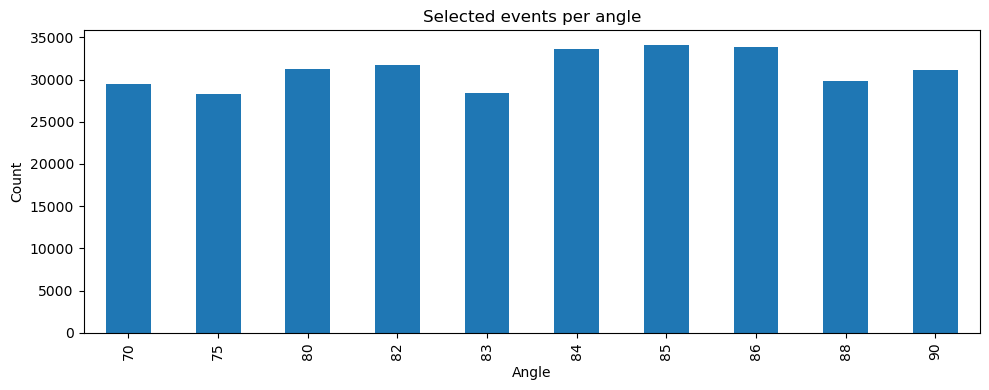

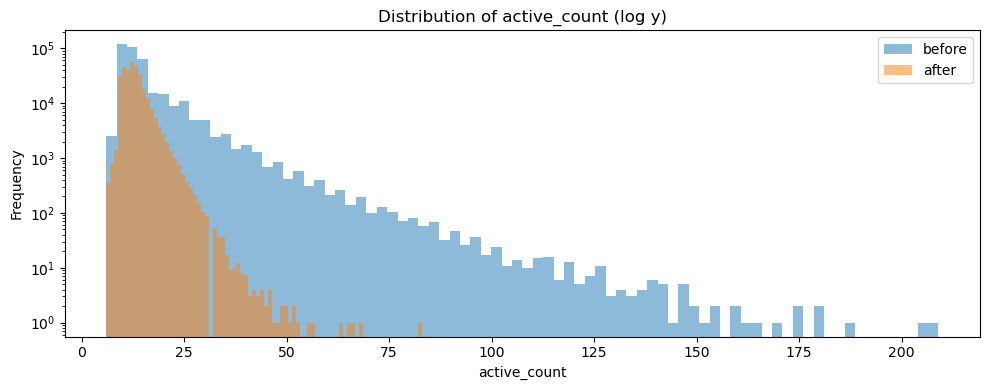

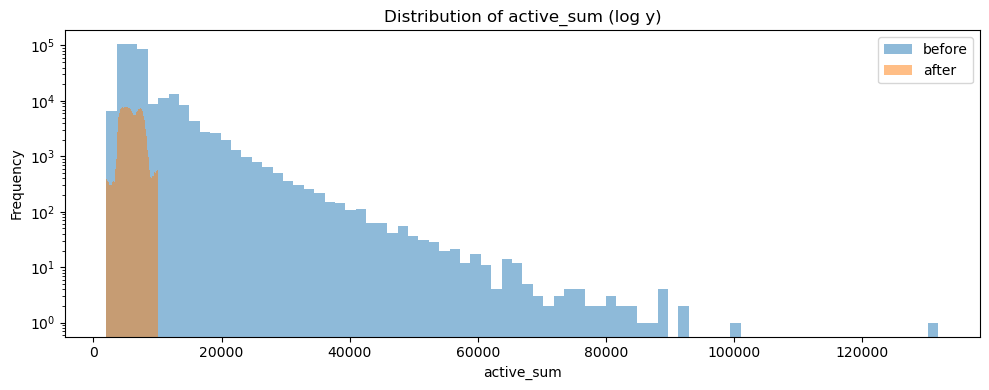

In [122]:
# 9) 统计与可视化（通过率、角度分布、关键字段分布）
import matplotlib.pyplot as plt

# 9.1 按角度通过数
angle_counts = manifest_df.groupby("angle").size().sort_index()

plt.figure(figsize=(10, 4))
angle_counts.plot(kind="bar")
plt.title("Selected events per angle")
plt.xlabel("Angle")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 9.2 active_count / active_sum 分布对比（若列存在）
for col in [ACTIVE_COUNT_COL, ACTIVE_SUM_COL]:
    if col not in features_df_angle.columns:
        print(f"skip plot: missing {col}")
        continue

    plt.figure(figsize=(10, 4))
    plt.hist(features_df_angle[col].values, bins=80, alpha=0.5, label="before")
    plt.hist(filtered_df[col].values, bins=80, alpha=0.5, label="after")
    plt.yscale("log")
    plt.title(f"Distribution of {col} (log y)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [123]:
# 10) 最小自检单元格（断言/一致性检查，便于在 VS Code 测试/运行）

required_cols = {"angle", FILENAME_COL, "raw_path", ACTIVE_COUNT_COL, ACTIVE_SUM_COL}
missing = [c for c in required_cols if c not in features_df.columns]
assert not missing, f"features_df 缺少列: {missing}"

# 角度筛选正确性（select 模式时）
if ANGLE_CFG.get("mode") == "select":
    angles_list = normalize_angles_param(ANGLE_CFG.get("angles"))
    if angles_list:
        assert set(filtered_df["angle"].astype(str)).issubset(set(angles_list)), "filtered_df 出现未选择的角度"
    else:
        a_min = ANGLE_CFG.get("angle_min")
        a_max = ANGLE_CFG.get("angle_max")
        s = pd.to_numeric(filtered_df["angle"], errors="coerce")
        if a_min is not None:
            assert (s >= float(a_min)).all(), "角度小于 angle_min"
        if a_max is not None:
            assert (s <= float(a_max)).all(), "角度大于 angle_max"

# 文件存在性：这里只做抽样检查（全量检查可能较慢）
np.random.seed(RANDOM_SEED)
if len(manifest_df) > 0:
    sample = manifest_df.sample(n=min(SANITY_CHECK_N, len(manifest_df)), random_state=RANDOM_SEED)
    missing_sample = []
    for r in sample.itertuples(index=False):
        p = Path(r.raw_path)
        if not p.exists():
            missing_sample.append(str(p))
    if missing_sample:
        print("WARNING: 抽样发现缺失文件（可能是 RAW_ROOT/FEATURE_ROOT 不对应）：")
        for p in missing_sample:
            print(" -", p)
    else:
        print("OK: 抽样文件路径均存在")

print("自检完成：")
print(" - features_df rows:", len(features_df))
print(" - after angle filter:", len(features_df_angle))
print(" - after conditions:", len(filtered_df))
print(" - manifest rows:", len(manifest_df))


OK: 抽样文件路径均存在
自检完成：
 - features_df rows: 363095
 - after angle filter: 363095
 - after conditions: 311673
 - manifest rows: 311673


In [124]:
# （可选）读取 txt 并快速复算 active_count / active_sum（用于更强的 sanity check）
# 注意：这一步会实际读取 txt，速度取决于磁盘与样本数量。

def load_event_matrix(path: Path, shape: Tuple[int, int] = (50, 50)) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.float32)
    if arr.shape != shape:
        raise ValueError(f"unexpected shape {arr.shape}, expected {shape}: {path}")
    return arr


def recompute_stats(arr: np.ndarray, *, active_threshold: float = 0.0) -> Tuple[int, float]:
    active = arr > active_threshold
    return int(active.sum()), float(arr[active].sum())


# 只对筛选结果抽样复算
if len(manifest_df) > 0:
    sample = manifest_df.sample(n=min(SANITY_CHECK_N, len(manifest_df)), random_state=RANDOM_SEED)
    for r in sample.itertuples(index=False):
        p = Path(r.raw_path)
        if not p.exists():
            print("missing:", p)
            continue
        arr = load_event_matrix(p)
        ac, s = recompute_stats(arr, active_threshold=0.0)
        print(f"{r.angle} {getattr(r, FILENAME_COL)}  recompute: active_count={ac}, active_sum={s:.3f} | csv: {getattr(r, ACTIVE_COUNT_COL)} {getattr(r, ACTIVE_SUM_COL)}")


88 C_r00000_0387_316.txt  recompute: active_count=14, active_sum=4110.497 | csv: 14 4110.4970703125
70 C_r00000_0544_093.txt  recompute: active_count=14, active_sum=5757.132 | csv: 14 5757.13232421875
85 C_r00000_0393_551.txt  recompute: active_count=27, active_sum=5177.395 | csv: 27 5177.39453125
86 C_r00000_0437_145.txt  recompute: active_count=12, active_sum=8072.994 | csv: 12 8072.99365234375
75 C_r00000_0518_040.txt  recompute: active_count=13, active_sum=7644.076 | csv: 13 7644.07568359375
